In [85]:
import cvxpy as cp
import numpy as np
import random
# Create three vector optimization variables.

# m agents and n assets
m=5
n=3

# we set the seed
random.seed(5)

agents = []

for _ in range(m):
    agent = {}
    agent['delta'] = random.randint(1, 100)
    agent['lambda'] = random.randint(1, 100)
    agent['asset_x'] = random.randint(0, n-1)
    agent['asset_y'] = random.randint(0, n-1)
    if agent['asset_x'] == agent['asset_y']:
        agent['asset_y'] = (agent['asset_y'] + 1) % n
    agents.append(agent)


# utils
one_m = np.ones(m)
zero_m = np.zeros(m)
zero_n = np.zeros(n)
identity_m = np.eye(m)
zero_matrix_nm = np.zeros((n,m))
zero_matrix_m = np.zeros((m,m))
epsilon_m = np.ones(m) * 1e-9
epsilon_n = np.ones(n) * 1e-9

(Delta, Lambda) = zip(*[(agent['delta'], agent['lambda']) for agent in agents])

# minimal exchange rate matrix
D = np.linalg.inv(np.diag(Delta)) @ np.diag(Lambda)

# We introude a permutation matrix parameter
Mx = np.zeros((n,m))
My = np.zeros((n,m))

for asset in range(n):
    for agent in range(m):
        if agents[agent]['asset_x'] == asset:
            Mx[asset, agent] = 1
        if agents[agent]['asset_y'] == asset:
            My[asset, agent] = 1

c= np.concatenate((zero_m, zero_m, one_m), axis=0)
A = np.concatenate((D, -identity_m, identity_m), axis=1)
b=zero_m
g1 = np.concatenate((-Mx, My, zero_matrix_nm), axis=1)
g2 = np.concatenate((identity_m, zero_matrix_m, zero_matrix_m), axis=1)
g3 = np.concatenate((-identity_m, zero_matrix_m, zero_matrix_m), axis=1)
g4 = np.concatenate((zero_matrix_m, -identity_m, zero_matrix_m), axis=1)
g5 = np.concatenate((zero_matrix_m, zero_matrix_m,  -identity_m), axis=1)
G = np.concatenate((g1,g2,g3,g4,g5), axis=0)

h = np.concatenate((-epsilon_n, Delta, -epsilon_m, -epsilon_m, -epsilon_m), axis=0)


# # We perform the linear program optimization
# max <c,x>
# s.t. Ax = b
# Gx <= h

t = cp.Variable(3*m)
objective = cp.Maximize(c @ t)
constraints = [A @ t == b, G @ t <= h]
prob = cp.Problem(objective, constraints)
result = prob.solve(solver=cp.CLARABEL, verbose=False)

x = t.value[0:m]
y = t.value[m:2*m]
z = t.value[2*m:3*m]

for (j,agent) in enumerate(agents):
    print("Agent {} wants to sell {} of asset {} and to collect at least {} of asset {} (implicit price : {} asset {}/ asset {})".format(j, agent['delta'], agent['asset_x'], agent['lambda'], agent['asset_y'], D[j][j], agent['asset_x'], agent['asset_y']))

for (j,agent) in enumerate(agents):
    print("Agent {} sells {} of asset {} and receives {} of asset {} (implicit price : {} asset {}/ asset {} >= min price {} asset {}/ asset {})".format(j, x[j], agent['asset_x'], y[j], agent['asset_y'], y[j]/x[j], agent['asset_x'], agent['asset_y'], D[j][j], agent['asset_x'], agent['asset_y']))

print(f"{Mx @ x} - {My @ y} = { Mx @ x - My @ y}")












Agent 0 wants to sell 80 of asset 2 and to collect at least 33 of asset 1 (implicit price : 0.41250000000000003 asset 2/ asset 1)
Agent 1 wants to sell 89 of asset 2 and to collect at least 95 of asset 0 (implicit price : 1.0674157303370786 asset 2/ asset 0)
Agent 2 wants to sell 4 of asset 0 and to collect at least 60 of asset 2 (implicit price : 15.0 asset 0/ asset 2)
Agent 3 wants to sell 7 of asset 0 and to collect at least 21 of asset 1 (implicit price : 3.0 asset 0/ asset 1)
Agent 4 wants to sell 61 of asset 1 and to collect at least 32 of asset 2 (implicit price : 0.5245901639344263 asset 1/ asset 2)
Agent 0 sells 79.99999997933843 of asset 2 and receives 42.21849920160084 of asset 1 (implicit price : 0.5277312401563075 asset 2/ asset 1 >= min price 0.41250000000000003 asset 2/ asset 1)
Agent 1 sells 6.7502276798956174e-09 of asset 2 and receives 1.0233681629332187e-08 of asset 0 (implicit price : 1.516049845223952 asset 2/ asset 0 >= min price 1.0674157303370786 asset 2/ asset 

Note: you may need to restart the kernel to use updated packages.


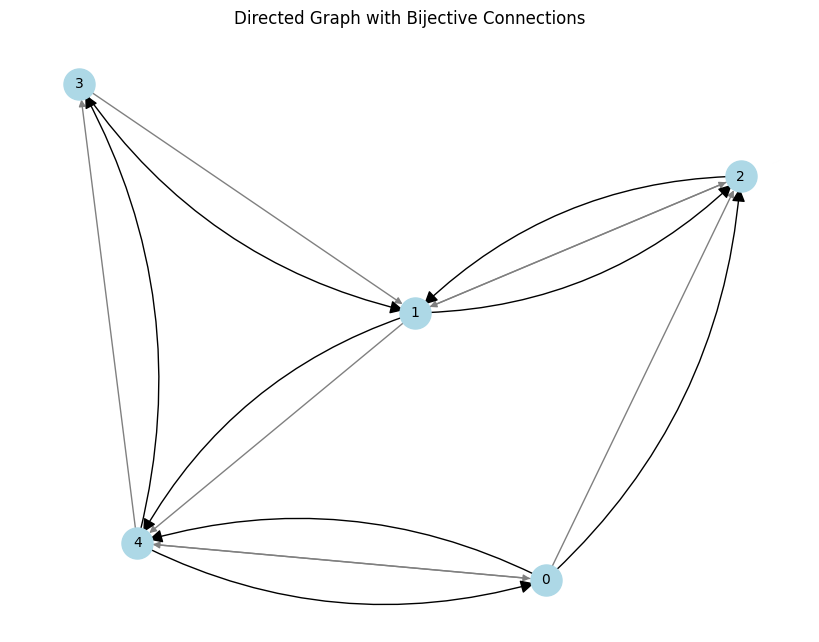

In [84]:
%pip install networkx
import networkx as nx
import matplotlib.pyplot as plt

adj_matrix = Mx.T @ My

# Create a directed graph from the adjacency matrix
G = nx.DiGraph()

# Add edges to the graph
for i in range(adj_matrix.shape[0]):
    for j in range(adj_matrix.shape[1]):
        if adj_matrix[i, j] != 0:
            G.add_edge(i, j)

# Draw the directed graph with curved edges
plt.figure(figsize=(8, 6))
pos = nx.spring_layout(G)  # Layout for better visualization
nx.draw(G, pos, with_labels=True, node_color='lightblue', edge_color='gray', node_size=500, font_size=10)
nx.draw_networkx_edges(G, pos, edgelist=G.edges(), arrowstyle='-|>', arrowsize=20, connectionstyle='arc3,rad=0.2')
plt.title("Directed Graph with Bijective Connections")
plt.show()